In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords
from string import punctuation
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import gensim
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score,accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
import pickle

In [3]:

df=df = pd.read_csv("email_spam_classifier_dataset.csv", encoding="latin1")

In [4]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2472,spam,Final Chance! Claim ur å£150 worth of discount...,NaN,NaN,NaN
4258,ham,Sad story of a Man - Last week was my b'day. M...,NaN,NaN,NaN
3578,ham,Multiply the numbers independently and count d...,NaN,NaN,NaN
430,ham,At home watching tv lor.,NaN,NaN,NaN
194,ham,How are you doing? Hope you've settled in for ...,NaN,NaN,NaN
3352,ham,I emailed yifeng my part oredi.. Can Ì_ get it...,NaN,NaN,NaN
329,ham,I'm reading the text i just sent you. Its mean...,NaN,NaN,NaN
5336,ham,Sounds better than my evening im just doing my...,NaN,NaN,NaN
1414,ham,So wats ur opinion abt him and how abt is char...,NaN,NaN,NaN
5467,spam,Get your garden ready for summer with a FREE s...,NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [8]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [9]:

df.duplicated().sum()

np.int64(403)

In [10]:
df=df.drop_duplicates()

In [11]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5126
Unnamed: 3    5159
Unnamed: 4    5164
dtype: int64

In [12]:
#removing the last 3 cols
df=df.iloc[:, 0:2]

In [13]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [14]:
#changing col name
df=df.rename(columns={'v1':'target', 'v2':'emails'})

In [15]:
df.head()

,target,emails
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
#changing ham=0 and spam=1 using lable encoder

le=LabelEncoder()
df.target=le.fit_transform(df.target)
df.head()

,target,emails
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df.isnull().sum()

target    0
emails    0
dtype: int64

In [18]:
data=df.target.value_counts()
data

target
0    4516
1     653
Name: count, dtype: int64

[]

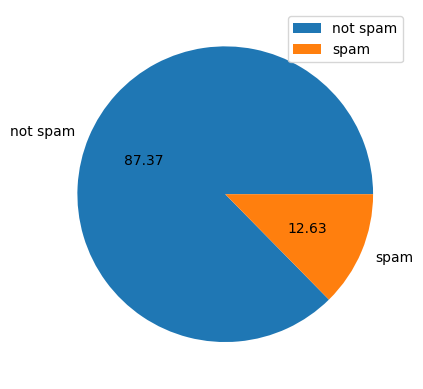

In [19]:
#pie plot of spam not spam
labels=['not spam', 'spam']
data=data
plt.pie(data, labels=labels, autopct='%.2f')
plt.legend()
plt.plot()

In [20]:
#so imbalance dataset

In [21]:
#char size
df['char_size']=df.emails.apply(len)

In [22]:
#no of words
df['word_size']=df.emails.apply(lambda x: len(nltk.word_tokenize(x)))

In [23]:
df

,target,emails,char_size,word_size
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [24]:
#sentence size
df['sent_size']=df.emails.apply(lambda x: len(nltk.sent_tokenize(x)))

In [25]:
df.head()

,target,emails,char_size,word_size,sent_size
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
print('not spam')
df[df['target']==0].describe()

not spam


,target,char_size,word_size,sent_size
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [27]:
print('spam')
df[df['target']==1].describe()

spam


,target,char_size,word_size,sent_size
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


#for spam
char size >100
word size >24
sent size > 2

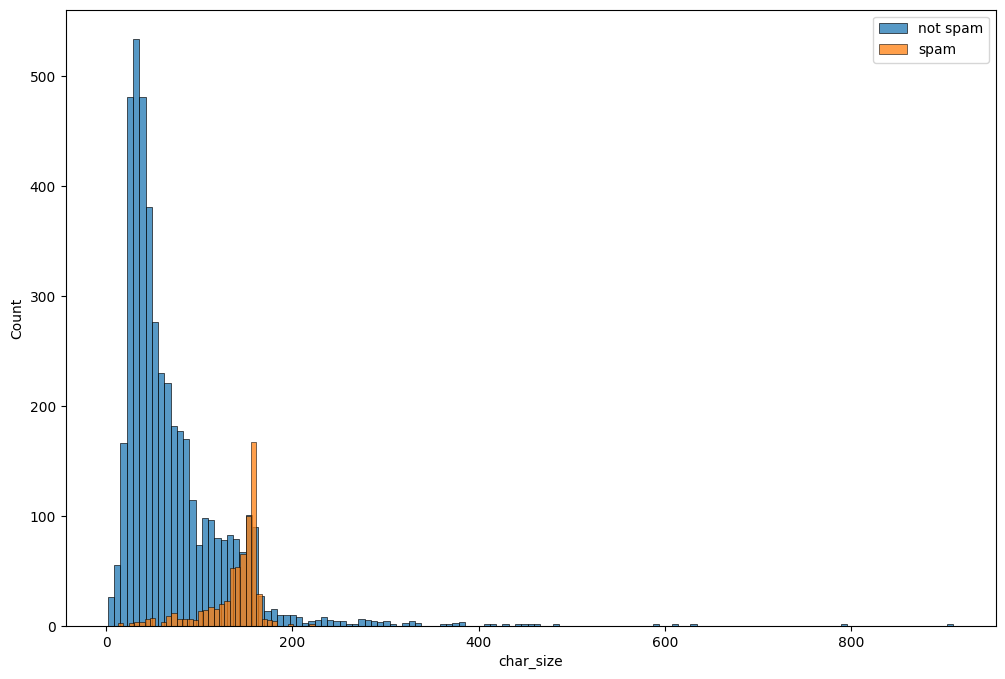

In [28]:

plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['char_size'] ,label="not spam")
#plt.show()


sns.histplot(df[df['target']==1]['char_size'], label='spam')
plt.legend()
plt.show()

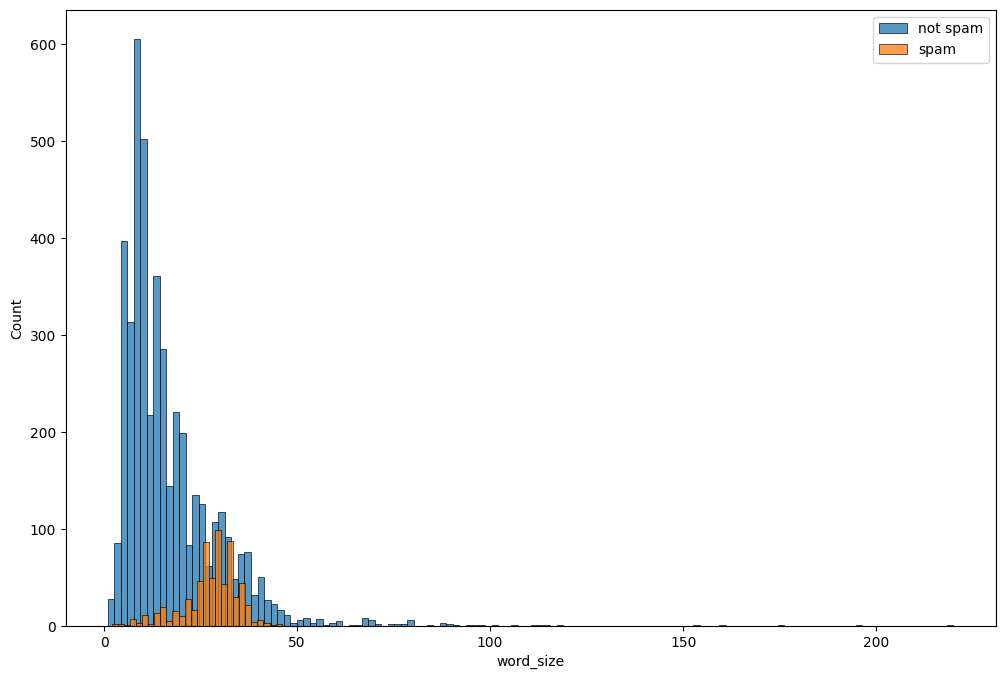

In [29]:

plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['word_size'] ,label="not spam")
#plt.show()

sns.histplot(df[df['target']==1]['word_size'], label='spam')
plt.legend()
plt.show()

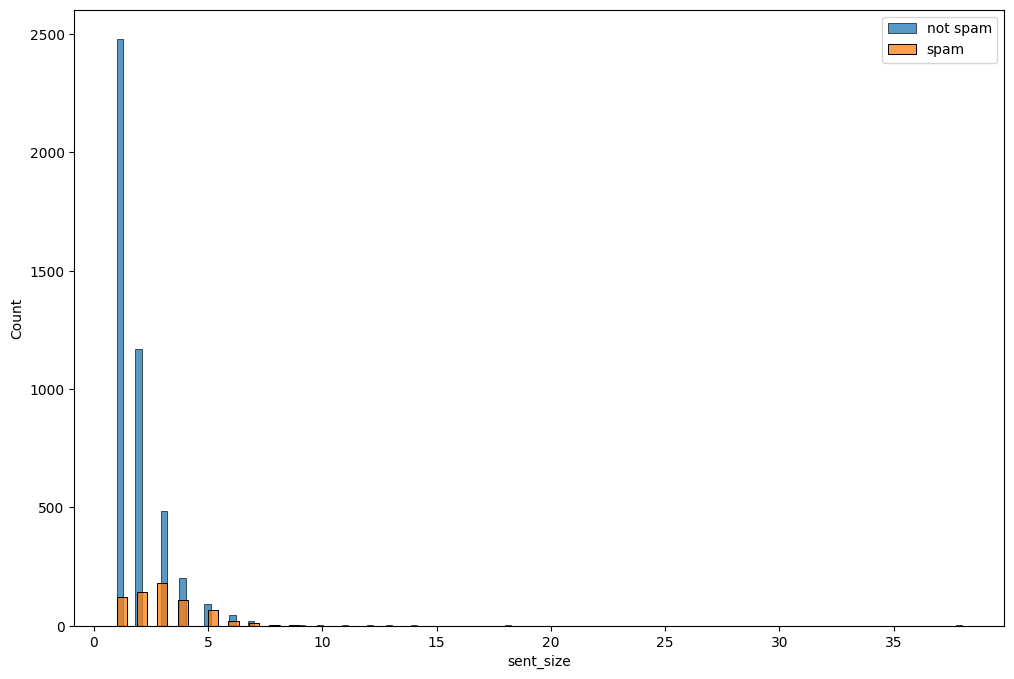

In [30]:

plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['sent_size'] ,label="not spam")
#plt.show()

sns.histplot(df[df['target']==1]['sent_size'], label='spam')
plt.legend()
plt.show()

array([[<Axes: title={'center': 'target'}>,
        <Axes: title={'center': 'char_size'}>],
       [<Axes: title={'center': 'word_size'}>,
        <Axes: title={'center': 'sent_size'}>]], dtype=object)

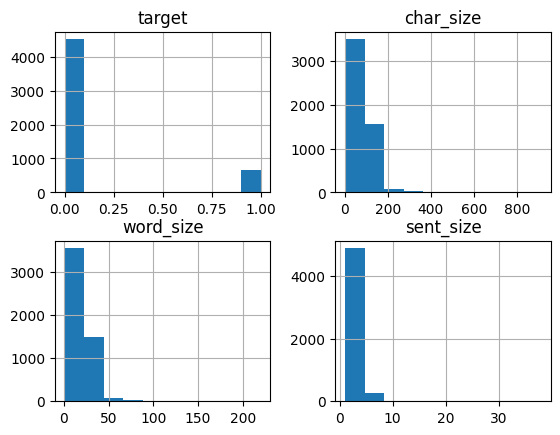

In [31]:
df.hist()

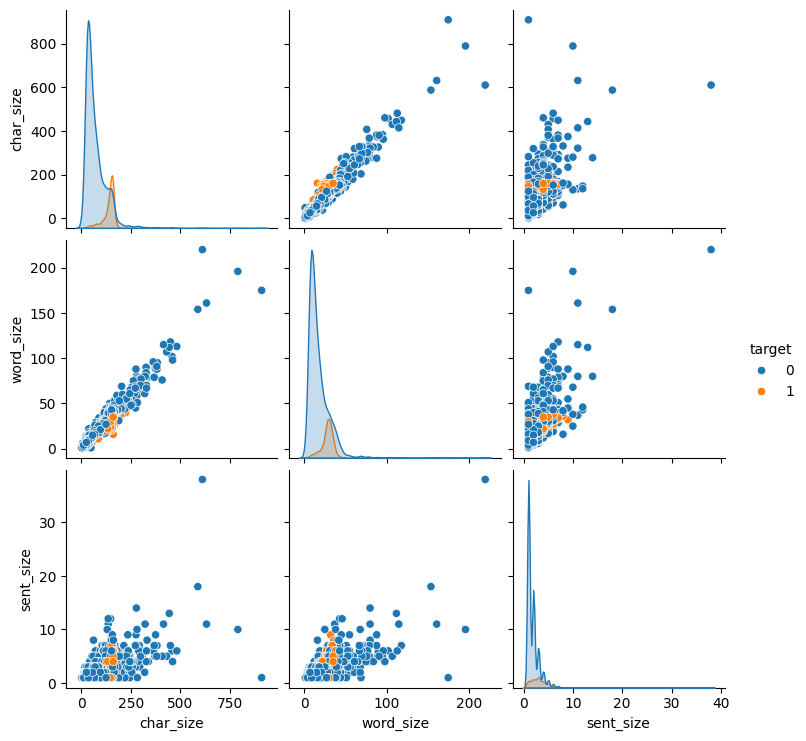

In [32]:
sns.pairplot(df,hue='target')

<Axes: >

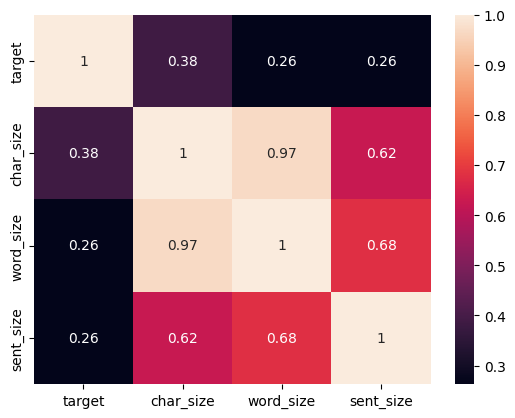

In [33]:
sns.heatmap(df.drop('emails',axis=1).corr(), annot=True)

In [34]:
df.head()

,target,emails,char_size,word_size,sent_size
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [35]:
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [36]:
stopword_list=stopwords.words('english')

stopword_list

In [37]:
#preprocessing lower tokenize remove sp ch, stopword, punc  and stemming
def preprocess(row):
    #lowercase
    row=row.lower()

    #word tokenize
    row=nltk.word_tokenize(row)

    #remove special char symbols
    y=[]
    for i in row:
        if i.isalnum():
            y.append(i)

    row=y[:]
    y.clear()

    #stemming with remove stopword and punctuation
    y=[PorterStemmer().stem(word) for word in row if word not in stopword_list and word not in punctuation]

    #return by forming string
    return " ".join(y)

In [38]:
preprocess("EXAMple hi he she it 34%% TeXt and cycling")
#preprocess("did tokens likeing mying pres")

'exampl hi 34 text cycl'

In [39]:
df['transformed_emails']=df.emails.apply(preprocess)

In [40]:
 df.head()

,target,emails,char_size,word_size,sent_size,transformed_emails
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


!pip install wordcloud

In [41]:
from wordcloud import WordCloud
wc=WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [42]:
spam_wc= wc.generate(df[df['target']==1]['transformed_emails'].str.cat(sep=" "))

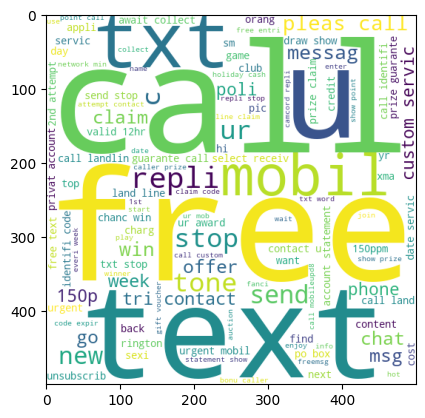

In [43]:
plt.imshow(spam_wc)

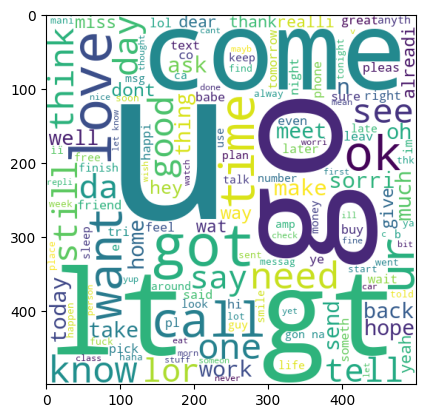

In [44]:
not_spam_wc= wc.generate(df[df['target']==0]['transformed_emails'].str.cat(sep=" "))
plt.imshow(not_spam_wc)

In [45]:
#getting the most frequent 30 words

In [46]:
sent_list=df[df['target']==1]['transformed_emails'].tolist()

In [47]:
spam_corpus=[]
for sent in sent_list:
    for word in sent.split():
        spam_corpus.append(word)

spam_corpus

In [48]:
from collections import Counter
spam_df=pd.DataFrame(Counter(spam_corpus).most_common(30))

[]

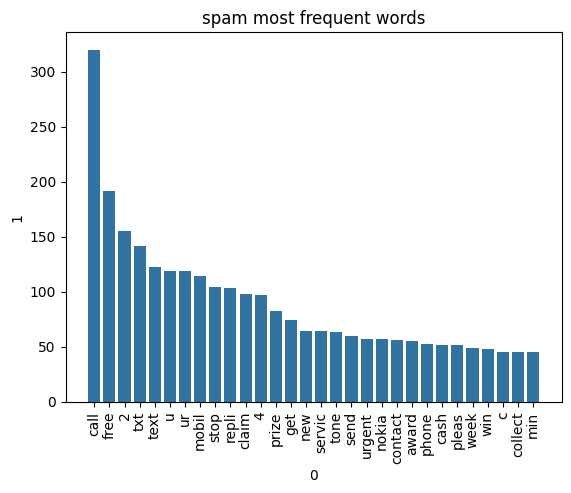

In [49]:
sns.barplot(x=spam_df[0], y=spam_df[1])
plt.title('spam most frequent words')
plt.xticks(rotation='vertical')
plt.plot()

[]

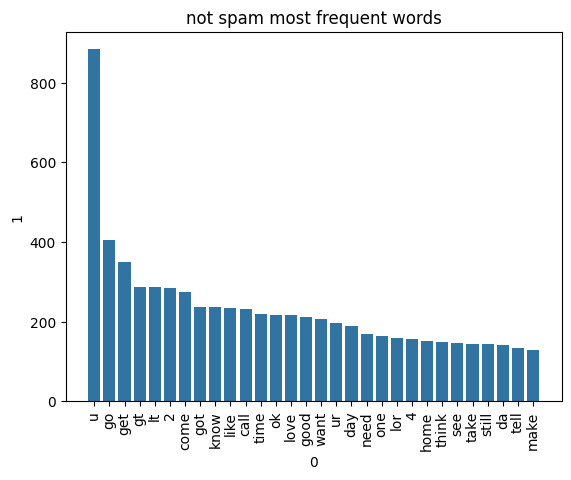

In [50]:
sent_list=df[df['target']==0]['transformed_emails'].tolist()
not_spam_corpus=[]
for sent in sent_list:
    for word in sent.split():
        not_spam_corpus.append(word)

not_spam_df=pd.DataFrame(Counter(not_spam_corpus).most_common(30))
sns.barplot(x=not_spam_df[0], y=not_spam_df[1])
plt.title('not spam most frequent words')
plt.xticks(rotation='vertical')
plt.plot()

to convert text to vectors
bag of words
tf-idf
word2vec

#model trainings
naive bayes
logistic regression
random tree classifier
decision tree classifier


In [51]:
df.shape

(5169, 6)

In [52]:
df

,target,emails,char_size,word_size,sent_size,transformed_emails
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [53]:
#bag of words

In [54]:
bow=CountVectorizer()
X_bow=bow.fit_transform(df.transformed_emails).toarray()

In [55]:
X_bow.shape

(5169, 6708)

In [56]:
y=df.target.values
y.shape

(5169,)

In [57]:
#tf-idf
tfidf=TfidfVectorizer()

In [58]:
X_tfidf=tfidf.fit_transform(df.transformed_emails).toarray()
X_tfidf.shape

(5169, 6708)

In [59]:
#word2vec
corpus=[]

for email in df.transformed_emails:
    corpus.append(email.split())

corpus

In [60]:
model=Word2Vec(
    sentences=corpus,
    window=5,
    min_count=3,
    #vector_size=100,
)

model.wv.index_to_key

In [61]:
print(model.corpus_count)
print(model.epochs)

5169
5


In [62]:
model.wv.similar_by_word('free')

[('mobil', 0.9996935725212097),
 ('txt', 0.9996750950813293),
 ('text', 0.9996547102928162),
 ('repli', 0.9996399879455566),
 ('4', 0.9996227622032166),
 ('msg', 0.999606192111969),
 ('phone', 0.9996044039726257),
 ('stop', 0.9995978474617004),
 ('tone', 0.9995952248573303),
 ('nokia', 0.9995912909507751)]

In [63]:
model.wv['free']

array([-0.4042275 ,  0.46605238,  0.12924719,  0.10196339,  0.15617593,
       -0.72449344,  0.18453005,  1.0425422 , -0.39142475, -0.19385257,
       -0.27360773, -0.7776708 , -0.18321177,  0.2136103 , -0.00204539,
       -0.44013044, -0.12182669, -0.6550002 ,  0.07758669, -1.0361304 ,
        0.12969889,  0.3769419 ,  0.1883797 , -0.05512242, -0.13541217,
        0.11072856, -0.5075614 , -0.41617778, -0.43804538,  0.14759599,
        0.31315133,  0.13752043,  0.1916445 , -0.21230917, -0.20715089,
        0.68281376,  0.10527939, -0.44649246, -0.2523649 , -0.96040356,
       -0.03852702, -0.56678647, -0.2230413 ,  0.17275311,  0.37780932,
       -0.22052781, -0.26104525, -0.09449774,  0.33070028,  0.33766168,
        0.23496816, -0.65095377, -0.12208883, -0.07377119, -0.3187057 ,
        0.23215556,  0.20573416, -0.10424746, -0.62617207,  0.28683296,
        0.248595  ,  0.12838727, -0.15950586, -0.19444212, -0.5017031 ,
        0.41064695,  0.24218628,  0.45851827, -0.7659546 ,  0.41

In [64]:
corpus[0]

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat']

In [65]:
def email_to_vector(sent):
    vectors=[]
    for word in sent:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors)==0:
        return np.zeros(model.vector_size)

    return np.mean(vectors,axis=0)
        

In [66]:
X_w2v=[]
for sent in corpus:
    X_w2v.append(email_to_vector(sent))

X_w2v=np.array(X_w2v)
X_w2v.shape

(5169, 100)

In [67]:
model_names=[]
text_names=[]
accuracy_scores=[]
precision_scores=[]

In [68]:

models_df = pd.DataFrame({
    "Model_Name": [
        "GaussianNB",
        "MultinomialNB",
        "BernoulliNB",
        "LogisticRegression",
        "DecisionTree",
        "RandomForest",
        "KNN"
    ],
    
    "Model_Object": [
        GaussianNB(),
        MultinomialNB(),
        BernoulliNB(),
        LogisticRegression(),
        DecisionTreeClassifier(class_weight='balanced'),
        RandomForestClassifier(class_weight='balanced'),
        KNeighborsClassifier()
    ]
})

In [69]:
features = {
    "BoW": X_bow,
    "TF-IDF": X_tfidf
}

In [70]:


# train models
for data_name, data in features.items():

    X_train, X_test, y_train, y_test = train_test_split(
        data, y, test_size=0.2, random_state=42
    )

    for name, model in zip(models_df['Model_Name'], models_df['Model_Object']):

        print(f"Running model: {name} with {data_name}")

        text_names.append(data_name)
        model_names.append(name)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)

        print(f'accuracy_score {acc}')
        print(f'precision_score {prec}')

        accuracy_scores.append(round(acc,2))
        precision_scores.append(round(prec,2))

        print('*'*50)
        print('\n')

Running model: GaussianNB with BoW
accuracy_score 0.8684719535783365
precision_score 0.5185185185185185
**************************************************


Running model: MultinomialNB with BoW
accuracy_score 0.9738878143133463
precision_score 0.8881578947368421
**************************************************


Running model: BernoulliNB with BoW
accuracy_score 0.9661508704061895
precision_score 0.9661016949152542
**************************************************


Running model: LogisticRegression with BoW
accuracy_score 0.97678916827853
precision_score 0.9689922480620154
**************************************************


Running model: DecisionTree with BoW
accuracy_score 0.9564796905222437
precision_score 0.8333333333333334
**************************************************


Running model: RandomForest with BoW
accuracy_score 0.9642166344294004
precision_score 1.0
**************************************************


Running model: KNN with BoW
accuracy_score 0.90425531914893

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
        X_w2v, y, test_size=0.2, random_state=42
    )
for name, model in zip(models_df['Model_Name'], models_df['Model_Object']):
    if(name=="MultinomialNB"):
            continue
    print(f"Running model: {name} with Word2Vec")

        

    text_names.append('Word2Vec')
    model_names.append(name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    print(f'accuracy_score {acc}')
    print(f'precision_score {prec}')

    accuracy_scores.append(round(acc,2))
    precision_scores.append(round(prec,2))

    print('*'*50)
    print('\n')

Running model: GaussianNB with Word2Vec
accuracy_score 0.4526112185686654
precision_score 0.18906942392909898
**************************************************


Running model: BernoulliNB with Word2Vec
accuracy_score 0.8597678916827853
precision_score 0.0
**************************************************


Running model: LogisticRegression with Word2Vec
accuracy_score 0.8597678916827853
precision_score 0.0
**************************************************


Running model: DecisionTree with Word2Vec


C:\Users\bhara\anaconda3\envs\thirdyear\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bhara\anaconda3\envs\thirdyear\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


accuracy_score 0.8916827852998066
precision_score 0.6187050359712231
**************************************************


Running model: RandomForest with Word2Vec
accuracy_score 0.9477756286266924
precision_score 0.941747572815534
**************************************************


Running model: KNN with Word2Vec
accuracy_score 0.9390715667311412
precision_score 0.7847222222222222
**************************************************




In [72]:
print(len(model_names))
print(len(text_names))
print(len(precision_scores))
print(len(accuracy_scores))

20
20
20
20


In [73]:
result=pd.DataFrame({
    'models':model_names,
    'text':text_names,
    'precision':precision_scores,
    'accuracy':accuracy_scores
})

In [74]:
result

,models,text,precision,accuracy
0,GaussianNB,BoW,0.52,0.87
1,MultinomialNB,BoW,0.89,0.97
2,BernoulliNB,BoW,0.97,0.97
3,LogisticRegression,BoW,0.97,0.98
4,DecisionTree,BoW,0.83,0.96
5,RandomForest,BoW,1.00,0.96
6,KNN,BoW,1.00,0.90
7,GaussianNB,TF-IDF,0.51,0.86
8,MultinomialNB,TF-IDF,0.99,0.96
9,BernoulliNB,TF-IDF,0.97,0.97


In [75]:
result.sort_values(by=["precision","accuracy"], ascending=False)

,models,text,precision,accuracy
12,RandomForest,TF-IDF,1.00,0.97
5,RandomForest,BoW,1.00,0.96
6,KNN,BoW,1.00,0.90
13,KNN,TF-IDF,1.00,0.90
8,MultinomialNB,TF-IDF,0.99,0.96
3,LogisticRegression,BoW,0.97,0.98
2,BernoulliNB,BoW,0.97,0.97
9,BernoulliNB,TF-IDF,0.97,0.97
10,LogisticRegression,TF-IDF,0.94,0.95
18,RandomForest,Word2Vec,0.94,0.95


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'GaussianNB'),
  Text(1, 0, 'MultinomialNB'),
  Text(2, 0, 'BernoulliNB'),
  Text(3, 0, 'LogisticRegression'),
  Text(4, 0, 'DecisionTree'),
  Text(5, 0, 'RandomForest'),
  Text(6, 0, 'KNN')])

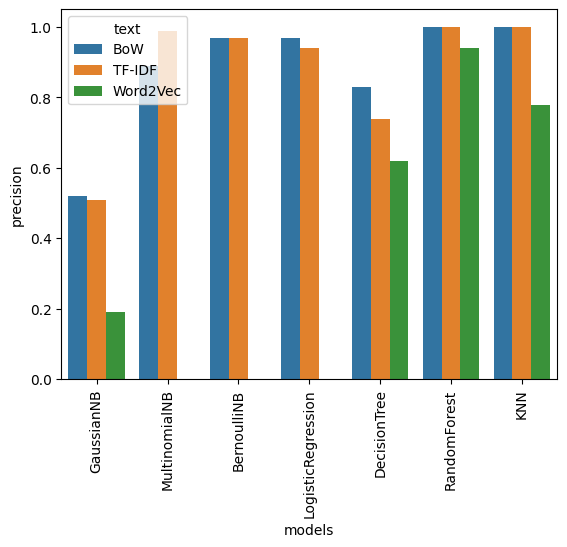

In [76]:
sns.barplot(data=result, x="models", y="precision", hue="text")
plt.xticks(rotation='vertical')

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2)

model =RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       884
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



In [78]:
#randome forest with tfidf data

<Axes: >

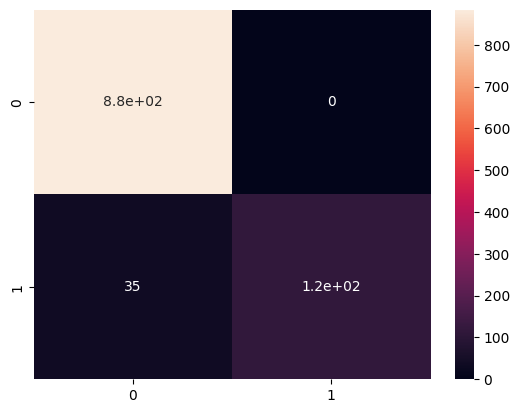

In [79]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [80]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_tfidf, y, cv=5,scoring="precision")

print(scores.mean())

0.997979797979798


In [81]:
X=df.transformed_emails
y=df.target

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [83]:
def preprocess_transform(X):
    return [preprocess(text) for text in X]


preprocessor = FunctionTransformer(preprocess_transform)

In [84]:
pipe=make_pipeline(
    preprocessor,
    TfidfVectorizer(),
    RandomForestClassifier(class_weight='balanced')
)

In [85]:
pipe.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('functiontransformer', ...), ('tfidfvectorizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function pre...0013A2832E8E0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyw

In [86]:
y_pred=pipe.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       903
           1       1.00      0.79      0.89       131

    accuracy                           0.97      1034
   macro avg       0.99      0.90      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [87]:
#user text
text=["Congratulations! You have won a $1000 Walmart gift card. Click the link to claim your prize now."]
#text=["Please send me the project report when you finish it."]
prediction=pipe.predict(text)
if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Spam


In [88]:
#the most spam words

In [89]:
feature_names = tfidf.get_feature_names_out()

In [90]:
importances = model.feature_importances_

In [91]:
import pandas as pd

feature_importance = pd.DataFrame({
    "word": feature_names,
    "importance": importances
})

In [92]:
top_words = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(top_words.head(20))

         word  importance
1436     call    0.061039
6137      txt    0.034773
2610     free    0.027900
5878     text    0.023619
3962    mobil    0.022143
4964    repli    0.018444
1617    claim    0.017721
5630     stop    0.017567
4726    prize    0.015441
5225   servic    0.011881
4140      new    0.011000
6494      win    0.009558
6229       ur    0.009141
1489     cash    0.008999
1742  contact    0.008390
1677  collect    0.007602
1865   custom    0.007297
5207     send    0.007207
4488      per    0.006809
1031    award    0.006620


In [93]:
#save data
pickle.dump(pipe,open("email_spam_classifier_project/pipeline.pkl","wb"))


In [94]:
#to load data
final_model=pickle.load(open('email_spam_classifier_project/pipeline.pkl','rb'))

In [95]:
final_model.predict(["Congratulations! You have won a $1000 Walmart gift card. Click the link to claim your prize now."])

array([1])